In [1]:
import matplotlib
matplotlib.use('agg')
import matplotlib.pyplot as plt
import io
import builtins
import IPython.display as ipd
from IPython.display import display as original_display, Image
def custom_display(*objs, **kwargs):
    for obj in objs:
        if hasattr(obj, 'savefig'):
            buf = io.BytesIO()
            obj.savefig(buf, format='png', bbox_inches='tight')
            buf.seek(0)
            original_display(Image(data=buf.read(), format='png'))
        else:
            original_display(obj, **kwargs)
ipd.display = custom_display
builtins.display = custom_display
def custom_show():
    buf = io.BytesIO()
    plt.savefig(buf, format='png', bbox_inches='tight')
    buf.seek(0)
    original_display(Image(data=buf.read(), format='png'))
    plt.clf()
plt.show = custom_show


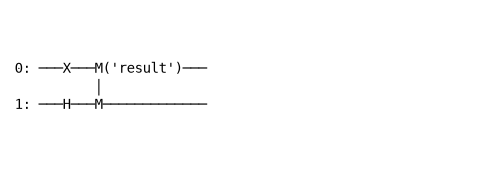

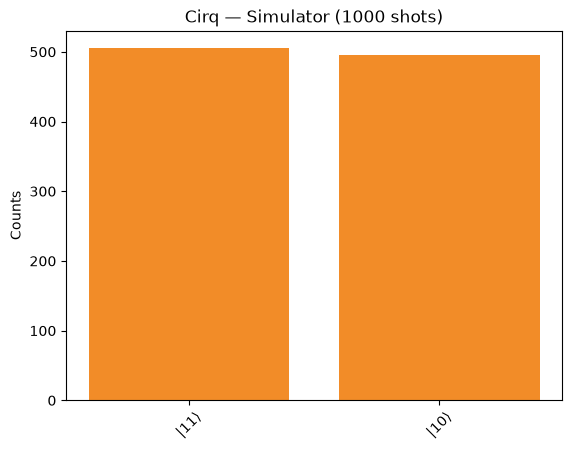

In [2]:
import cirq
import matplotlib.pyplot as plt

qubits = cirq.LineQubit.range(2)
circuit = cirq.Circuit()
circuit.append(cirq.X(qubits[0]))
circuit.append(cirq.H(qubits[1]))
circuit.append(cirq.measure(*qubits, key="result"))

fig, ax = plt.subplots(figsize=(max(6, 2), 2))
ax.text(0.01, 0.5, str(circuit), fontfamily="monospace", fontsize=10, va="center")
ax.axis("off")
display(fig)
plt.close(fig)

simulator = cirq.Simulator()
result = simulator.run(circuit, repetitions=1000)
hist = result.histogram(key="result")
labels = [f"|{format(k, '02b')}⟩" for k in hist.keys()]
fig2, ax2 = plt.subplots()
ax2.bar(labels, hist.values(), color="#f28c28")
ax2.set_ylabel("Counts")
ax2.set_title("Cirq — Simulator (1000 shots)")
plt.xticks(rotation=45)
display(fig2)
plt.close(fig2)
